<a href="https://colab.research.google.com/github/Mans-doc/MDQ/blob/main/business_cards_MDQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

df = pd.read_parquet('/content/sample_data/business_cards_MDQ.parquet')


In [20]:

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997593 entries, 0 to 2997592
Data columns (total 13 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_date        object        
 1   transaction_timestamp   datetime64[ms]
 2   transaction_amount_kzt  int64         
 3   mcc                     object        
 4   merchant_id             object        
 5   channel                 object        
 6   bank_name               object        
 7   country                 object        
 8   card_number             object        
 9   tokenized               bool          
 10  is_recurring            bool          
 11  day_of_week             int32         
 12  is_weekend              int64         
dtypes: bool(2), datetime64[ms](1), int32(1), int64(2), object(7)
memory usage: 245.9+ MB


,transaction_timestamp,transaction_amount_kzt,day_of_week,is_weekend
count,2997593,2.997593e+06,2.997593e+06,2.997593e+06
mean,2026-01-01 23:22:32.938000,1.565353e+05,2.452974e+00,1.245119e-01
min,2025-10-01 00:00:00,6.700000e+01,0.000000e+00,0.000000e+00
25%,2025-11-17 15:42:00,2.283500e+04,1.000000e+00,0.000000e+00
50%,2026-01-01 13:32:36,7.722400e+04,2.000000e+00,0.000000e+00
75%,2026-02-17 16:16:51,1.960810e+05,4.000000e+00,0.000000e+00
max,2026-03-31 23:59:53,4.079930e+07,6.000000e+00,1.000000e+00
std,NaN,2.528682e+05,1.754553e+00,3.301647e-01


In [8]:
df.isnull().sum()

,0
transaction_date,0
transaction_timestamp,0
transaction_amount_kzt,0
mcc,0
merchant_id,0
channel,0
bank_name,0
country,0
card_number,0
card_tier,0


In [9]:
df['transaction_amount_kzt'].describe()

,transaction_amount_kzt
count,2.997593e+06
mean,1.565353e+05
std,2.528682e+05
min,6.700000e+01
25%,2.283500e+04
50%,7.722400e+04
75%,1.960810e+05
max,4.079930e+07


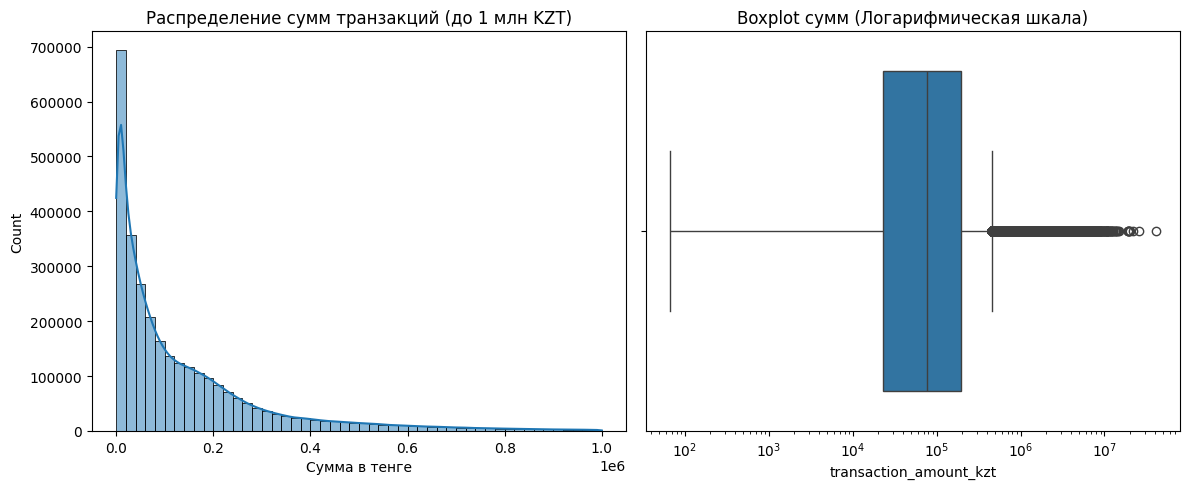

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[df['transaction_amount_kzt'] < 1000000]['transaction_amount_kzt'], bins=50, kde=True)
plt.title('Распределение сумм транзакций (до 1 млн KZT)')
plt.xlabel('Сумма в тенге')


plt.subplot(1, 2, 2)
sns.boxplot(x=df['transaction_amount_kzt'])
plt.xscale('log')
plt.title('Boxplot сумм (Логарифмическая шкала)')

plt.tight_layout()
plt.show()

In [11]:
categorical_cols = ['mcc', 'bank_name', 'country', 'card_tier', 'channel']
for col in categorical_cols:
    print(f"Столбец {col}: {df[col].nunique()} уникальных значений")

Столбец mcc: 104 уникальных значений
Столбец bank_name: 11 уникальных значений
Столбец country: 18 уникальных значений
Столбец card_tier: 1 уникальных значений
Столбец channel: 2 уникальных значений


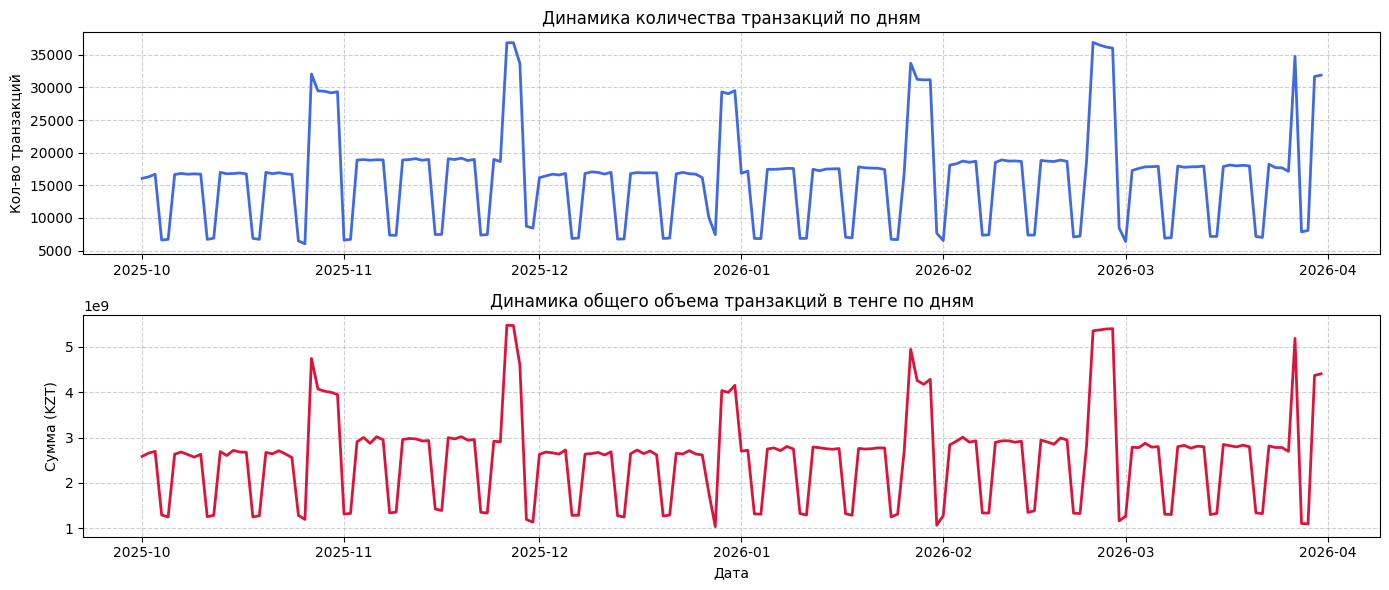

In [16]:

daily_stats = df.groupby(df['transaction_timestamp'].dt.date).agg(
    transaction_count=('transaction_amount_kzt', 'count'),
    total_amount=('transaction_amount_kzt', 'sum')
).reset_index()

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(daily_stats['transaction_timestamp'], daily_stats['transaction_count'], color='royalblue', linewidth=2)
plt.title('Динамика количества транзакций по дням')
plt.ylabel('Кол-во транзакций')
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(2, 1, 2)
plt.plot(daily_stats['transaction_timestamp'], daily_stats['total_amount'], color='crimson', linewidth=2)
plt.title('Динамика общего объема транзакций в тенге по дням')
plt.ylabel('Сумма (KZT)')
plt.xlabel('Дата')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

df['day_of_week'] = df['transaction_timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

daily_stats = df.groupby(df['transaction_timestamp'].dt.date).agg(
    transaction_count=('transaction_amount_kzt', 'count'),
    total_amount=('transaction_amount_kzt', 'sum'),
    weekend_transactions_count=('is_weekend', 'sum')
).reset_index()

print(daily_stats.head())

  transaction_timestamp  transaction_count  total_amount  \
0            2025-10-01              16063    2584336542   
1            2025-10-02              16299    2657864600   
2            2025-10-03              16704    2695948453   
3            2025-10-04               6629    1296240252   
4            2025-10-05               6734    1252562089   

   weekend_transactions_count  
0                           0  
1                           0  
2                           0  
3                        6629  
4                        6734  


In [21]:

client_features = df.groupby('card_number').agg(
    total_transactions=('transaction_amount_kzt', 'count'),
    total_volume_kzt=('transaction_amount_kzt', 'sum'),
    mean_transaction=('transaction_amount_kzt', 'mean'),
    median_transaction=('transaction_amount_kzt', 'median'),
    max_transaction=('transaction_amount_kzt', 'max'),


    weekend_trans_ratio=('is_weekend', 'mean'),
    unique_merchants=('merchant_id', 'nunique'),
    unique_mccs=('mcc', 'nunique'),

    recurring_ratio=('is_recurring', 'mean'),
    tokenized_ratio=('tokenized', 'mean')
).reset_index()

client_features.to_parquet('client_features_ready.parquet', index=False)
